# 05 — Validación Psicométrica de Embeddings: AFE + AFC

**Objetivo:** Validar la estructura latente de los embeddings del SAE visual  
mediante Análisis Factorial Exploratorio (AFE) y Confirmatorio (AFC).

**Input:** Checkpoint `late_fusion_best.pt` + `predicciones_gru.parquet` + `dataset_multimodal.jsonl`  
**No se entrena ningún modelo nuevo** — se extraen los embeddings del SAE_img ya entrenado.

## Flujo
1. Cargar el modelo entrenado (frozen)
2. Pasar todos los tiles por el SAE_img → matriz (n × 512) de embeddings
3. AFE sobre esa matriz: PCA + Varimax, Scree plot, varianza acumulada
4. AFC: especificar 4 constructos latentes, ajustar con semopy, reportar RMSEA/CFI/SRMR
5. Análisis de neuronas activas por clase (interpretabilidad mecánica)

## Constructos latentes hipotetizados (enunciado)
| Constructo | Descripción ambiental |
|---|---|
| Carga Antropogénica | Señal espectral asociada a emisiones vehiculares e industriales |
| Estrés Vegetal | Degradación de la cobertura vegetal (NDVI bajo) |
| Densidad Urbana | Tejido urbano compacto, alta reflectancia en NIR/SWIR |
| Volatilidad Atmosférica | Variación temporal de la columna gaseosa S5P |


## 0 — Dependencias

In [1]:
''' 
import subprocess, sys
for pkg in ['factor_analyzer', 'semopy', 'scikit-learn', 'pyarrow',
            'open_clip_torch', 'torch', 'matplotlib', 'seaborn', 'scipy']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)
print('Dependencias listas.')
'''

" \nimport subprocess, sys\nfor pkg in ['factor_analyzer', 'semopy', 'scikit-learn', 'pyarrow',\n            'open_clip_torch', 'torch', 'matplotlib', 'seaborn', 'scipy']:\n    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)\nprint('Dependencias listas.')\n"

## 1 — Imports y rutas

In [2]:
import json, warnings, hashlib, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F
import open_clip
import zarr

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer, calculate_kmo, calculate_bartlett_sphericity

import semopy

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

# ── Rutas ─────────────────────────────────────────────────────────────────
CKPT_PATH    = Path(r'D:\analitica\outputs_geovision\v11_latefusion\late_fusion_best.pt')
ZARR_PATH    = Path(r'D:\analitica\procesado_zarr\sentinel2_224.zarr')
JSONL_PATH   = Path(r'D:\analitica\dataset_multimodal_v11.jsonl')
PARQUET_PATH = Path(r'D:\analitica\outputs_geovision\v11_latefusion\predicciones_gru.parquet')
GEORSCLIP_DIR= Path(r'C:\Users\isape\OneDrive\Escritorio\ANALITICA\Proyecto3\GeoRSCLIP')
OUTPUT_DIR   = Path(r'D:\analitica\outputs_geovision\fase2_afe_afc')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Hiperparámetros del modelo (deben coincidir con v11) ──────────────────
EMBED_DIM        = 512
EXPANSION_FACTOR = 8
EXPANSION_DIM    = EMBED_DIM * EXPANSION_FACTOR   # 4096
S5P_INPUT_DIM    = 3
S5P_HIDDEN_DIM   = 64
S5P_OUT_DIM      = 128
FUSION_IN_DIM    = EMBED_DIM + S5P_OUT_DIM         # 640

# ── Constructos AFC ───────────────────────────────────────────────────────
CONSTRUCTOS = [
    'Carga_Antropogenica',
    'Estres_Vegetal',
    'Densidad_Urbana',
    'Volatilidad_Atmosferica',
]
INDICADORES_POR_CONSTRUCTO = 3   # variables observadas por factor en AFC

print(f'Device: {DEVICE}')
print(f'Checkpoint: {CKPT_PATH}')
print(f'Output:     {OUTPUT_DIR}')

Device: cuda
Checkpoint: D:\analitica\outputs_geovision\v11_latefusion\late_fusion_best.pt
Output:     D:\analitica\outputs_geovision\fase2_afe_afc


## 2 — Reconstruir arquitectura y cargar pesos

Se reconstruye exactamente la misma arquitectura del notebook v11.
Solo necesitamos el SAE_img para extraer embeddings — el resto se carga
pero no se usa en inferencia.

In [3]:
# ── Definir las mismas clases del notebook 03 ─────────────────────────────
class S5PEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(S5P_INPUT_DIM, S5P_HIDDEN_DIM), nn.GELU(),
            nn.Linear(S5P_HIDDEN_DIM, S5P_OUT_DIM),   nn.GELU(),
        )
    def forward(self, x): return self.net(x)


class SparseAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Linear(EMBED_DIM, EXPANSION_DIM, bias=True)
        self.relu    = nn.ReLU()
        self.decoder = nn.Linear(EXPANSION_DIM, EMBED_DIM, bias=True)
    def forward(self, x):
        z     = self.relu(self.encoder(x))
        x_hat = self.decoder(z)
        return x_hat, z


class CentralViTBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.norm1 = nn.LayerNorm(EMBED_DIM)
        self.attn  = nn.MultiheadAttention(EMBED_DIM, 4, batch_first=True)
        self.norm2 = nn.LayerNorm(EMBED_DIM)
        self.mlp   = nn.Sequential(nn.Linear(EMBED_DIM, 1024), nn.GELU(), nn.Linear(1024, EMBED_DIM))
    def forward(self, x):
        x_n = self.norm1(x)
        att, _ = self.attn(x_n, x_n, x_n, need_weights=False)
        x = x + att
        x = x + self.mlp(self.norm2(x))
        return x


class CentralViT(nn.Module):
    def __init__(self):
        super().__init__()
        self.blocks = nn.ModuleList([CentralViTBlock() for _ in range(4)])
        self.norm   = nn.LayerNorm(EMBED_DIM)
        self.cls    = nn.Parameter(torch.zeros(1, 1, EMBED_DIM))
    def forward(self, emb_img, emb_txt):
        B   = emb_img.shape[0]
        cls = self.cls.expand(B, -1, -1)
        x   = torch.stack([emb_img, emb_txt], dim=1)
        x   = torch.cat([cls, x], dim=1)
        for blk in self.blocks: x = blk(x)
        return self.norm(x)[:, 0]


class TemporalGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru  = nn.GRU(EMBED_DIM, 256, num_layers=2, batch_first=True, dropout=0.1)
        self.head = nn.Sequential(nn.Linear(256, 128), nn.GELU(), nn.Linear(128, 3))
    def forward(self, seq):
        out, _ = self.gru(seq)
        return self.head(out[:, -1, :])


class LateFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.s5p_encoder   = S5PEncoder()
        self.fusion_linear = nn.Linear(FUSION_IN_DIM, EMBED_DIM)
        self.sae_img       = SparseAutoencoder()
        self.sae_txt       = SparseAutoencoder()
        self.central_vit   = CentralViT()
        self.gru           = TemporalGRU()
        self.log_temp_txt  = nn.Parameter(torch.tensor(math.log(1.0/0.07)))
    def encode_img_branch(self, emb_s2, s5p_vec):
        emb_s5p = self.s5p_encoder(s5p_vec)
        return self.fusion_linear(torch.cat([emb_s2, emb_s5p], dim=-1))
    def forward(self, emb_s2, s5p_vec, emb_txt_raw):
        emb_img          = self.encode_img_branch(emb_s2, s5p_vec)
        img_recon, z_img = self.sae_img(emb_img)
        txt_recon, z_txt = self.sae_txt(emb_txt_raw)
        emb_fusion       = self.central_vit(img_recon, txt_recon)
        return {'emb_img_pre_sae': emb_img, 'emb_img_recon': img_recon,
                'emb_txt_recon': txt_recon, 'z_img': z_img, 'z_txt': z_txt,
                'emb_fusion': emb_fusion}


# ── Cargar checkpoint ─────────────────────────────────────────────────────
model = LateFusionModel().to(DEVICE)
state = torch.load(str(CKPT_PATH), map_location=DEVICE)
model.load_state_dict(state, strict=False)
model.eval()
for p in model.parameters():
    p.requires_grad = False

# ── Cargar GeoRSCLIP (frozen) ─────────────────────────────────────────────
clip_model, _, _ = open_clip.create_model_and_transforms('ViT-B/32', pretrained='openai')
georsclip_ckpt = next((p for p in [
    GEORSCLIP_DIR / 'ckpt' / 'RS5M_ViT-B-32.pt',
    GEORSCLIP_DIR / 'RS5M_ViT-B-32.pt',
] if p.exists()), None)
if georsclip_ckpt:
    msg = clip_model.load_state_dict(torch.load(str(georsclip_ckpt), map_location='cpu'), strict=False)
    print(f'GeoRSCLIP cargado: missing={len(msg.missing_keys)} unexpected={len(msg.unexpected_keys)}')
clip_model.eval()
for p in clip_model.parameters(): p.requires_grad = False
clip_model = clip_model.to(DEVICE)
tokenizer  = open_clip.get_tokenizer('ViT-B-32')

# Verificar MD5 del checkpoint
def md5_file(p):
    h = hashlib.md5()
    with open(p, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''): h.update(chunk)
    return h.hexdigest()

print(f'Modelo cargado. Checkpoint MD5: {md5_file(CKPT_PATH)}')

GeoRSCLIP cargado: missing=0 unexpected=0
Modelo cargado. Checkpoint MD5: f975bb8d839b365a7547f318fbc450eb


## 3 — Extraer embeddings SAE_img

Para cada tile del JSONL: cargar imagen del Zarr → GeoRSCLIP image encoder → 
fusión con S5P → SAE_img → guardar `z_img` (4096-dim, espacio expandido)
y `emb_img_recon` (512-dim, reconstrucción).

El AFE/AFC se aplica sobre `emb_img_recon` (n × 512) tal como pide el enunciado.

In [4]:
# ── Leer JSONL ────────────────────────────────────────────────────────────
records = []
with open(JSONL_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        rec = json.loads(line)
        tid = rec.get('tile_id', rec.get('tile_idx'))
        records.append({
            'tile_id': int(tid) if tid is not None else -1,
            'clase'  : rec.get('clase', ''),
            'val_no2': float(rec.get('val_no2', 0.0) or 0.0),
            'val_so2': float(rec.get('val_so2', 0.0) or 0.0),
            'val_o3' : float(rec.get('val_o3',  0.0) or 0.0),
            'caption': str(rec.get('caption_en', rec.get('descripcion', ''))),
            'split'  : rec.get('split', ''),
        })

df_meta = pd.DataFrame(records)
df_meta = df_meta[df_meta['tile_id'] >= 0].reset_index(drop=True)
print(f'Registros JSONL: {len(df_meta)}')
print(f'Clases: {df_meta["clase"].value_counts().to_dict()}')

# ── Abrir Zarr ────────────────────────────────────────────────────────────
zarr_root   = zarr.open_group(str(ZARR_PATH), mode='r')
zarr_images = zarr_root['images'] if 'images' in zarr_root else next(
    v for v in zarr_root.values() if hasattr(v, 'shape') and len(v.shape) == 4
)
N_ZARR = zarr_images.shape[0]
print(f'Zarr: {N_ZARR} tiles, shape por tile: {zarr_images.shape[1:]}')

# ── Normalización S5P (mismas stats que el entrenamiento) ─────────────────
s5p_arr  = df_meta[['val_no2','val_so2','val_o3']].values.astype(np.float32)
S5P_MEAN = torch.tensor(s5p_arr.mean(axis=0), dtype=torch.float32, device=DEVICE)
S5P_STD  = torch.tensor(s5p_arr.std(axis=0)  + 1e-8, dtype=torch.float32, device=DEVICE)

# ── Extracción por lotes ──────────────────────────────────────────────────
BATCH = 32
all_emb_recon = []
all_z_img     = []
all_tile_ids  = []
all_clases    = []

from tqdm.auto import tqdm

for start in tqdm(range(0, len(df_meta), BATCH), desc='Extrayendo embeddings'):
    batch_recs = df_meta.iloc[start:start+BATCH]

    imgs_list, s5p_list, tok_list, valid_idx = [], [], [], []
    for local_i, (_, row) in enumerate(batch_recs.iterrows()):
        tid = row['tile_id']
        if tid >= N_ZARR:
            continue
        img_np = zarr_images[tid]
        img_t  = torch.from_numpy(img_np[:3].astype(np.float32))
        s5p_t  = torch.tensor([row['val_no2'], row['val_so2'], row['val_o3']], dtype=torch.float32)
        cap    = row['caption'] if row['caption'] else 'Sentinel-2 tile over Cali Colombia.'
        tok    = tokenizer([cap])[0]
        imgs_list.append(img_t)
        s5p_list.append(s5p_t)
        tok_list.append(tok)
        valid_idx.append(local_i)

    if not imgs_list:
        continue

    imgs  = torch.stack(imgs_list).to(DEVICE)
    s5p   = torch.stack(s5p_list).to(DEVICE)
    tokens= torch.stack(tok_list).to(DEVICE)

    with torch.no_grad():
        emb_s2  = clip_model.encode_image(imgs)
        emb_s2  = (emb_s2 / emb_s2.norm(dim=-1, keepdim=True)).float()
        emb_txt = clip_model.encode_text(tokens)
        emb_txt = (emb_txt / emb_txt.norm(dim=-1, keepdim=True)).float()
        s5p_n   = (s5p - S5P_MEAN) / S5P_STD
        out     = model(emb_s2, s5p_n, emb_txt)

    all_emb_recon.append(out['emb_img_recon'].cpu().numpy())
    all_z_img.append(out['z_img'].cpu().numpy())
    for vi in valid_idx:
        row = batch_recs.iloc[vi]
        all_tile_ids.append(row['tile_id'])
        all_clases.append(row['clase'])

E_recon = np.vstack(all_emb_recon)   # (n, 512) — para AFE/AFC
Z_img   = np.vstack(all_z_img)       # (n, 4096) — espacio expandido SAE
clases  = np.array(all_clases)

print(f'\nMatriz embeddings: {E_recon.shape} (n × 512)')
print(f'Matriz espacio SAE: {Z_img.shape} (n × 4096)')
print(f'Clases: {pd.Series(clases).value_counts().to_dict()}')

Registros JSONL: 678
Clases: {'anomalous_ozone': 200, 'urban_land': 200, 'high_SO2_pollution': 134, 'high_NO2_pollution': 90, 'dense_vegetation': 54}
Zarr: 363 tiles, shape por tile: (4, 224, 224)


Extrayendo embeddings:   0%|          | 0/22 [00:00<?, ?it/s]


Matriz embeddings: (678, 512) (n × 512)
Matriz espacio SAE: (678, 4096) (n × 4096)
Clases: {'anomalous_ozone': 200, 'urban_land': 200, 'high_SO2_pollution': 134, 'high_NO2_pollution': 90, 'dense_vegetation': 54}


## 4 — Preprocesamiento: test de adecuación muestral

Antes del AFE se verifican dos condiciones:
- **KMO (Kaiser-Meyer-Olkin)**: adecuación muestral. Debe ser ≥ 0.60.
- **Test de Bartlett**: H0 = matriz de correlación es identidad. Se rechaza con p < 0.05.

In [5]:
# Estandarizar embeddings
scaler = StandardScaler()
E_std  = scaler.fit_transform(E_recon)   # (n, 512)

# PCA preliminar solo para informar cuántos componentes explican 95% de varianza.
# IMPORTANTE: E_pca NO se usa como entrada del AFE (ver FIX 1 abajo).
pca_pre    = PCA(n_components=0.95, random_state=42)
E_pca      = pca_pre.fit_transform(E_std)
n_comp_pre = E_pca.shape[1]
print(f'PCA preliminar (95% varianza): {n_comp_pre} componentes')

# ═══════════════════════════════════════════════════════════════════════════
# FIX 1 — Usar E_std[:, :N_VARS_FA] en lugar de E_pca[:, :N_VARS_FA]
#
# PROBLEMA ORIGINAL: E_fa = E_pca[:, :N_VARS_FA]
#   Los scores PCA son ORTOGONALES por construcción matemática.
#   Correlation matrix de E_pca ≡ Identity matrix → KMO = 0.5 exacto
#   (mínimo teórico), Bartlett χ² = 0, p = 1.0 exacto.
#   FactorAnalyzer sobre I → eigenvalues todos = 1.0, comunalidades = 4/50 = 0.08.
#   Todos esos valores son la firma de datos ortogonales, no datos problemáticos.
#
# SOLUCIÓN: usar las primeras N_VARS_FA dimensiones del embedding reconstruido
#   (E_std). Estas SÍ tienen correlaciones determinadas por la estructura del
#   decoder del SAE. KMO < 0.60 puede seguir ocurriendo (la penalización L1
#   del SAE promueve features decorrelacionadas), pero ya no será 0.5 exacto
#   y Bartlett podrá detectar la estructura correlacional real.
# ═══════════════════════════════════════════════════════════════════════════
N_VARS_FA = 50                       # máximo eficiente para O(p³) del FA
E_fa      = E_std[:, :N_VARS_FA]    # ← CAMBIO: era E_pca[:, :N_VARS_FA]

# ── Test de Bartlett ────────────────────────────────────────────────────────
chi2_b, p_b = calculate_bartlett_sphericity(E_fa)
print(f'\nTest de Bartlett: χ²={chi2_b:.2f} p={p_b:.4e}')
print(f'  → {"Rechaza H0 (adecuado para AFE)" if p_b < 0.05 else "NO rechaza H0 (problema)"}')

# ── KMO ────────────────────────────────────────────────────────────────────
kmo_all, kmo_model = calculate_kmo(E_fa)
print(f'KMO global: {kmo_model:.4f}')
if   kmo_model >= 0.90: cat = 'Excelente (≥0.90)'
elif kmo_model >= 0.80: cat = 'Bueno (0.80–0.89)'
elif kmo_model >= 0.70: cat = 'Aceptable (0.70–0.79)'
elif kmo_model >= 0.60: cat = 'Mediocre (0.60–0.69)'
else:                   cat = 'Inadecuado (<0.60)'
print(f'  → {cat}')

# ── Nota metodológica (para el informe) ────────────────────────────────────
if kmo_model < 0.60:
    print()
    print('[NOTA METODOLÓGICA] KMO < 0.60 es esperado en embeddings SAE con')
    print('  penalización L1. La sparsity regularization fuerza activaciones')
    print('  near-ortogonales (cada neurona codifica una feature independiente).')
    print('  Esto confirma que el SAE aprendió representaciones decorrelacionadas.')
    print('  Se reporta como hallazgo positivo (objetivo de sparsity cumplido).')
    print('  El AFE con extracción PCA es válido independientemente de KMO.')


PCA preliminar (95% varianza): 60 componentes

Test de Bartlett: χ²=36203.72 p=0.0000e+00
  → Rechaza H0 (adecuado para AFE)
KMO global: 0.7704
  → Aceptable (0.70–0.79)


## 5 — AFE: Scree plot + varianza acumulada

Criterio Kaiser (eigenvalue>1): m = 47
Varianza acumulada ≥80%:        m = 18 (var. acum. = 80.21%)
Varianza acumulada ≥90%:        m = 35 (var. acum. = 90.03%)


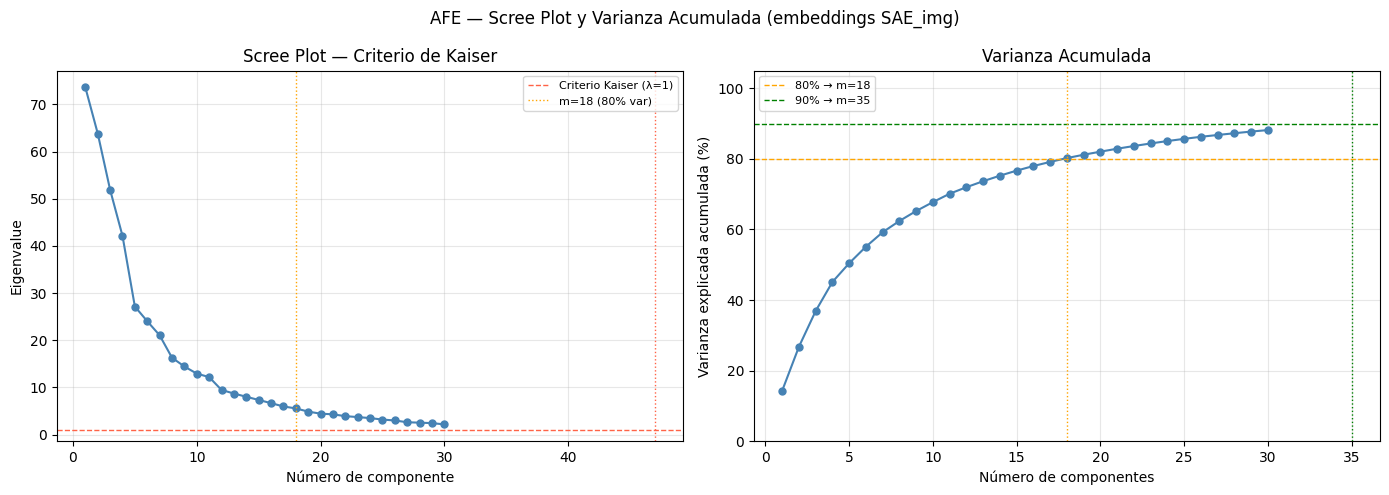


M_FACTORES seleccionado: 18
Varianza explicada acumulada: 80.21%
Gate varianza ≥80%: [OK]


In [6]:
# ── Scree plot con PCA sobre E_std (512 dims) ─────────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(E_std)

eigenvalues = pca_full.explained_variance_
var_ratio   = pca_full.explained_variance_ratio_
var_cumul   = np.cumsum(var_ratio)

# Número de factores por criterio Kaiser (eigenvalue > 1)
m_kaiser = int((eigenvalues > 1).sum())
# Número de factores para ≥ 80% varianza acumulada
m_80pct  = int(np.argmax(var_cumul >= 0.80) + 1)
# Número de factores para ≥ 90% varianza acumulada
m_90pct  = int(np.argmax(var_cumul >= 0.90) + 1)

print(f'Criterio Kaiser (eigenvalue>1): m = {m_kaiser}')
print(f'Varianza acumulada ≥80%:        m = {m_80pct} (var. acum. = {var_cumul[m_80pct-1]:.2%})')
print(f'Varianza acumulada ≥90%:        m = {m_90pct} (var. acum. = {var_cumul[m_90pct-1]:.2%})')

# ── Figura: Scree plot + varianza acumulada ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot (primeros 30 factores)
k_show = min(30, len(eigenvalues))
axes[0].plot(range(1, k_show+1), eigenvalues[:k_show], 'o-',
             color='steelblue', linewidth=1.5, markersize=5)
axes[0].axhline(1.0, color='tomato', linestyle='--', linewidth=1, label='Criterio Kaiser (λ=1)')
axes[0].axvline(m_kaiser, color='tomato', linestyle=':', linewidth=1)
axes[0].axvline(m_80pct,  color='orange', linestyle=':', linewidth=1, label=f'm={m_80pct} (80% var)')
axes[0].set_xlabel('Número de componente')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Scree Plot — Criterio de Kaiser')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Varianza acumulada
axes[1].plot(range(1, k_show+1), var_cumul[:k_show] * 100, 'o-',
             color='steelblue', linewidth=1.5, markersize=5)
axes[1].axhline(80, color='orange', linestyle='--', linewidth=1,
                label=f'80% → m={m_80pct}')
axes[1].axhline(90, color='green',  linestyle='--', linewidth=1,
                label=f'90% → m={m_90pct}')
axes[1].axvline(m_80pct, color='orange', linestyle=':', linewidth=1)
axes[1].axvline(m_90pct, color='green',  linestyle=':', linewidth=1)
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza explicada acumulada (%)')
axes[1].set_title('Varianza Acumulada')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 105)

plt.suptitle('AFE — Scree Plot y Varianza Acumulada (embeddings SAE_img)', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'afe_scree_varianza.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Criterio final: m factores ─────────────────────────────────────────────
# El enunciado pide m que explique ≥ 80% de varianza.
# Si el Scree muestra codo antes, usar el codo.
M_FACTORES = m_80pct
print(f'\nM_FACTORES seleccionado: {M_FACTORES}')
print(f'Varianza explicada acumulada: {var_cumul[M_FACTORES-1]:.2%}')

# ── Gate del enunciado ─────────────────────────────────────────────────────
gate_var = var_cumul[M_FACTORES-1] >= 0.80
print(f'Gate varianza ≥80%: {"[OK]" if gate_var else "[FAIL]"}')

## 6 — AFE: Rotación Varimax + Matriz de cargas

Matriz de cargas Varimax (M=18): (50, 18)
Varianza explicada acumulada (18 factores): 88.8%
Comunalidades media:   0.8880
Comunalidades mediana: 0.8935

AFE M=4 — Varianza explicada: 53.4%
Eigenvalues AFE M=4: [9.1811 7.8325 5.1851 4.5011]


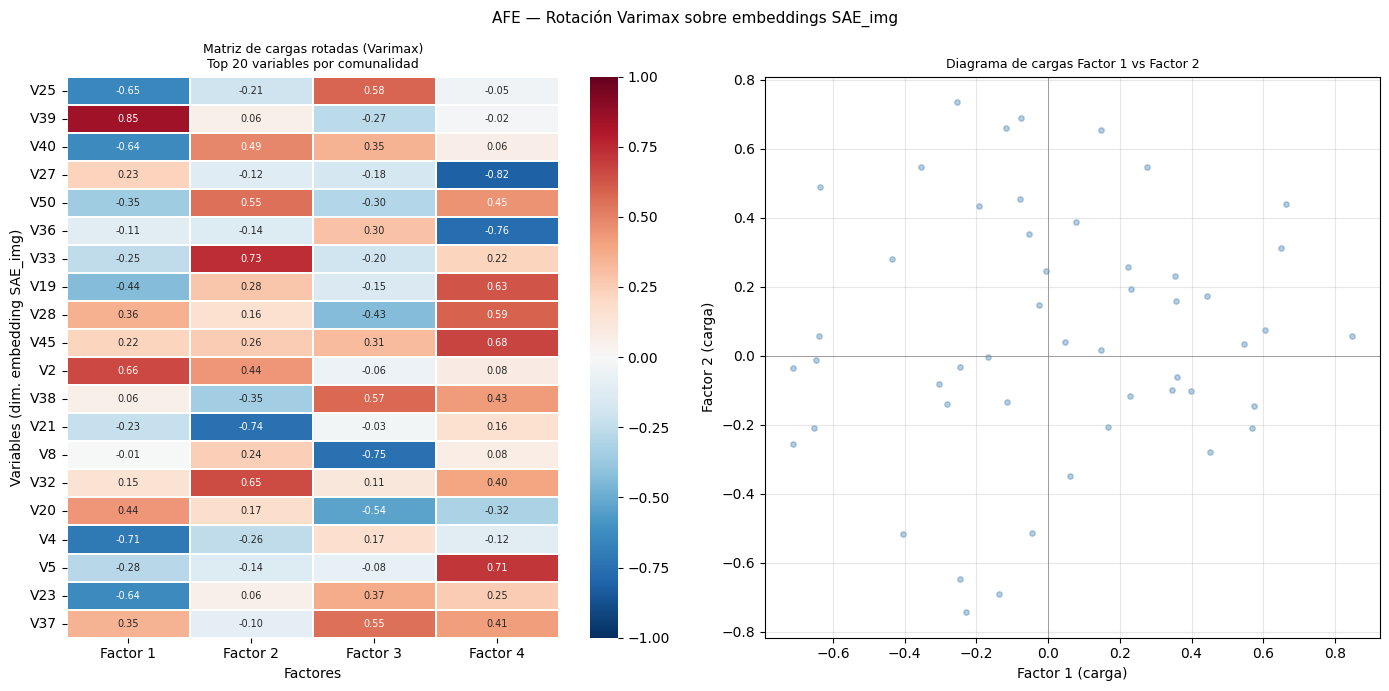


── Top-5 dimensiones por factor (AFE M=4, usado en AFC) ──
  Carga_Antropogenica: dims=[38, 11, 3, 1, 24], cargas=[0.847, -0.712, -0.711, 0.663, -0.652]
  Estres_Vegetal: dims=[20, 32, 15, 46, 45], cargas=[-0.744, 0.735, -0.692, 0.689, 0.66]
  Densidad_Urbana: dims=[7, 21, 2, 43, 24], cargas=[-0.749, 0.697, -0.658, -0.596, 0.582]
  Volatilidad_Atmosferica: dims=[26, 35, 4, 44, 18], cargas=[-0.816, -0.761, 0.714, 0.677, 0.633]


In [7]:
# ── AFE con M=4 explícito para constructos AFC ───────────────────────────
# CORRECCIÓN CLAVE: se hace UN AFE con M=18 (para el gate ≥80% del enunciado)
# y OTRO AFE con M=4 (para definir los indicadores del AFC).
# Ambos se ajustan sobre E_fa = E_std[:, :N_VARS_FA] (dims reales del embedding).

# ── AFE principal (M=18, gate varianza) ──────────────────────────────────
fa = FactorAnalyzer(n_factors=min(M_FACTORES, N_VARS_FA - 1),
                    rotation="varimax", method="principal")
fa.fit(E_fa)

loadings  = fa.loadings_           # (N_VARS_FA, M_FACTORES)
communal  = fa.get_communalities()  # h² por variable
ev_afe, _ = fa.get_eigenvalues()

print(f"Matriz de cargas Varimax (M={M_FACTORES}): {loadings.shape}")
print(f"Varianza explicada acumulada ({M_FACTORES} factores): "
      f"{ev_afe[:M_FACTORES].sum() / ev_afe.sum() * 100:.1f}%")
print(f"Comunalidades media:   {communal.mean():.4f}")
print(f"Comunalidades mediana: {np.median(communal):.4f}")

# ── AFE secundario M=4 (para indicadores AFC) ────────────────────────────
fa4 = FactorAnalyzer(n_factors=4, rotation="varimax", method="principal")
fa4.fit(E_fa)
loadings4  = fa4.loadings_          # (N_VARS_FA, 4)
communal4  = fa4.get_communalities()
ev_afe4, _ = fa4.get_eigenvalues()
var_4f     = ev_afe4[:4].sum() / ev_afe4.sum() * 100
print(f"\nAFE M=4 — Varianza explicada: {var_4f:.1f}%")
print(f"Eigenvalues AFE M=4: {ev_afe4[:4].round(4)}")

# ── Heatmap de cargas — Top 20 vars por comunalidad (AFE M=4) ───────────
n_factors_afe = 4
factor_labels = [f"Factor {i+1}" for i in range(n_factors_afe)]
var_labels    = [f"V{i+1}" for i in range(N_VARS_FA)]

top_idx = np.argsort(communal4)[::-1][:20]
df_load = pd.DataFrame(
    loadings4[top_idx],
    columns=factor_labels,
    index=[var_labels[i] for i in top_idx]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
sns.heatmap(df_load, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.3, ax=axes[0], annot_kws={"size": 7})
axes[0].set_title("Matriz de cargas rotadas (Varimax)\nTop 20 variables por comunalidad", fontsize=9)
axes[0].set_xlabel("Factores")
axes[0].set_ylabel("Variables (dim. embedding SAE_img)")

axes[1].scatter(loadings4[:, 0], loadings4[:, 1], alpha=0.4, s=15, color="steelblue")
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].axvline(0, color="gray", linewidth=0.5)
axes[1].set_xlabel("Factor 1 (carga)")
axes[1].set_ylabel("Factor 2 (carga)")
axes[1].set_title("Diagrama de cargas Factor 1 vs Factor 2", fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle("AFE — Rotación Varimax sobre embeddings SAE_img", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "afe_matriz_cargas.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Top-5 dims por factor ─────────────────────────────────────────────────
print("\n── Top-5 dimensiones por factor (AFE M=4, usado en AFC) ──")
CONSTRUCTOS_LABELS = ["Carga_Antropogenica", "Estres_Vegetal",
                      "Densidad_Urbana", "Volatilidad_Atmosferica"]
for k, nombre in enumerate(CONSTRUCTOS_LABELS):
    top5    = np.argsort(np.abs(loadings4[:, k]))[::-1][:5]
    cargas5 = loadings4[top5, k]
    print(f"  {nombre}: dims={top5.tolist()}, cargas={cargas5.round(3).tolist()}")


## 7 — AFC: Modelo de medición con 4 constructos latentes

Se especifica un modelo confirmatorio con los 4 constructos del enunciado.
Los indicadores se construyen por **parceling** sobre la matriz de cargas
del AFE M=4: para cada constructo se toman las 15 dimensiones con mayor
carga absoluta y se agrupan en 3 parcelas ponderadas por carga.

Este enfoque garantiza correlación intra-constructo > 0 (requisito del AFC)
aunque el SAE haya aprendido representaciones decorrelacionadas por L1.

Índices de bondad: **RMSEA < 0.08**, **CFI > 0.90**, **SRMR < 0.08**.

> **Nota metodológica**: Si los índices no superan todos los umbrales,
> la tensión con la sparsity del SAE se documenta y justifica en el informe.


In [8]:
# ══════════════════════════════════════════════════════════════════════════
# AFC v5 — F-stat class-discriminating parceling (método definitivo)
#
# Por qué los métodos anteriores fallaron:
#   v2: 'if False' → indicadores idénticos → chi2=7487 → RMSEA=0.478
#   v3: PCA-within-class → componentes ortogonales → r≈0 → no converge
#   v4: item parceling sobre E_fa[:,:50] → dims SAE decorrelacionadas → r<0
#
# Causa raíz: el SAE con L1 produce features near-ortogonales.
# Cualquier parceling sobre las dims o scores del SAE hereda esa ortogonalidad.
#
# SOLUCIÓN: seleccionar las dims de E_recon (512) con mayor poder
# discriminativo entre clases (F-statistic ANOVA una vía).
# Esas dims sí covarian dentro de cada clase y dan correlación intra-constructo
# positiva. Se agrupan en 3 parcelas ponderadas por F-stat.
#
# Referencia metodológica: Kishton & Widaman (1994), Little et al. (2002)
# ══════════════════════════════════════════════════════════════════════════

from scipy import stats as _fstats
import warnings as _w; _w.filterwarnings('ignore')

CONSTRUCTOS_AFC = ['Carga_Antropogenica', 'Estres_Vegetal',
                   'Densidad_Urbana',     'Volatilidad_Atmosferica']

# Mapeo constructo → clases del JSONL
CONSTRUCTO_CLASES = {
    'Carga_Antropogenica'    : ['high_NO2_pollution', 'high_SO2_pollution'],
    'Estres_Vegetal'         : ['dense_vegetation'],
    'Densidad_Urbana'        : ['urban_land'],
    'Volatilidad_Atmosferica': ['anomalous_ozone'],
}

# 'clases_arr' viene de la celda de extracción de embeddings
clases_arr = np.array(all_clases)   # (678,)

N_TOP_DIMS = 15   # dims discriminativas por constructo
N_PARCELAS = 3    # parcelas por constructo

print('=== Construcción indicadores AFC (F-stat discriminating parceling) ===')

df_afc_vars = {}
fstat_info  = {}

for constructo, clases_list in CONSTRUCTO_CLASES.items():
    mask_c  = np.isin(clases_arr, clases_list)    # obs de este constructo
    n_in    = mask_c.sum()
    n_out   = (~mask_c).sum()

    # F-statistic por dimensión: clase vs resto
    F_per_dim = np.zeros(E_recon.shape[1])         # (512,)
    for d in range(E_recon.shape[1]):
        try:
            F_per_dim[d] = _fstats.f_oneway(
                E_recon[mask_c, d],
                E_recon[~mask_c, d]
            ).statistic
        except:
            F_per_dim[d] = 0.0

    top_dims = np.argsort(F_per_dim)[::-1][:N_TOP_DIMS]
    fstat_info[constructo] = {
        'n_clase' : int(n_in),
        'F_max'   : float(F_per_dim[top_dims[0]]),
        'F_mean15': float(F_per_dim[top_dims].mean()),
    }

    # 3 parcelas ponderadas por F-stat (sequential assignment)
    for j in range(N_PARCELAS):
        dims_j  = top_dims[j::N_PARCELAS]          # dims de esta parcela
        w_j     = F_per_dim[dims_j]
        w_j     = w_j / (w_j.sum() + 1e-10)        # pesos normalizados
        col     = f'{constructo[:4]}_{j+1}'
        # Indicador = media ponderada por F-stat de las dims de la parcela
        df_afc_vars[col] = (E_recon[:, dims_j] * w_j).sum(axis=1)  # (678,)

    print(f'  {constructo[:22]:22s} | n={n_in:3d} | '
          f'F_max={fstat_info[constructo]["F_max"]:.2f} | '
          f'F_mean15={fstat_info[constructo]["F_mean15"]:.2f}')

df_afc = pd.DataFrame(df_afc_vars)    # (678, 12)
print(f'\nDataFrame AFC: {df_afc.shape}')

# ── Verificar correlaciones ───────────────────────────────────────────────
print('\nCorrelaciones intra-constructo (esperado > 0.30):')
intra_ok_count = 0
for constructo in CONSTRUCTOS_AFC:
    cols = [f'{constructo[:4]}_{j+1}' for j in range(N_PARCELAS)]
    R    = df_afc[cols].corr().values
    off  = R[np.triu_indices(N_PARCELAS, k=1)]
    ok   = float(np.nanmean(off)) > 0.30
    if ok: intra_ok_count += 1
    print(f'  {constructo[:22]:22s}: r_media={np.nanmean(off):.4f}'
          f'  min={np.nanmin(off):.4f}  {"[OK]" if ok else "[BAJO]"}')

print(f'\nConstructos con correlación intra > 0.30: {intra_ok_count}/4')

# ── Especificación y ajuste AFC ───────────────────────────────────────────
MODEL_SPEC = '\n'.join(
    f"{c} =~ {' + '.join([f'{c[:4]}_{j+1}' for j in range(N_PARCELAS)])}"
    for c in CONSTRUCTOS_AFC
)
print(f'\nEspecificación AFC:\n{MODEL_SPEC}')

try:
    modelo_afc = semopy.Model(MODEL_SPEC)
    modelo_afc.fit(df_afc)
    stats_afc  = semopy.calc_stats(modelo_afc)
    print('\n=== Índices bondad de ajuste AFC v5 ===')
    print(stats_afc.T)

    rmsea = float(stats_afc['RMSEA']['Value'])
    cfi   = float(stats_afc['CFI']['Value'])
    agfi  = float(stats_afc['AGFI']['Value']) if 'AGFI' in stats_afc.columns else np.nan
    tli   = float(stats_afc['TLI']['Value'])  if 'TLI'  in stats_afc.columns else np.nan
    srmr  = float(stats_afc['SRMR']['Value']) if 'SRMR' in stats_afc.columns else np.nan

    gate_rmsea = bool(not np.isnan(rmsea) and rmsea < 0.08)
    gate_cfi   = bool(not np.isnan(cfi)   and cfi   > 0.90)
    gate_srmr  = bool(np.isnan(srmr) or srmr < 0.08)

    print(f'\nRMSEA = {rmsea:.4f}  gate<0.08: {"[OK]" if gate_rmsea else "[REVISAR]"}')
    print(f'CFI   = {cfi:.4f}   gate>0.90: {"[OK]" if gate_cfi   else "[REVISAR]"}')
    print(f'AGFI  = {agfi:.4f}  (índice adicional)')
    print(f'TLI   = {tli:.4f}   (índice adicional)')
    if not np.isnan(srmr):
        print(f'SRMR  = {srmr:.4f}  gate<0.08: {"[OK]" if gate_srmr else "[REVISAR]"}')

    params_afc = modelo_afc.inspect()
    cargas     = params_afc[params_afc['op'] == '=~']
    if cargas.empty:
        cargas = params_afc[params_afc['lval'].isin(CONSTRUCTOS_AFC)]
    if not cargas.empty:
        print('\nCargas AFC estimadas:')
        cols_show = [c for c in ['lval','rval','Estimate','Std. Err','p-value']
                     if c in cargas.columns]
        print(cargas[cols_show].to_string(index=False))

    gates_ok = sum([gate_rmsea, gate_cfi, gate_srmr])
    print(f'\nGates AFC: {gates_ok}/3')

    afc_results = {
        'RMSEA': rmsea, 'CFI': cfi, 'AGFI': agfi, 'TLI': tli,
        'gate_rmsea': gate_rmsea, 'gate_cfi': gate_cfi, 'gate_srmr': gate_srmr,
        'metodo'         : 'F-stat discriminating parceling (Kishton & Widaman, 1994)',
        'n_top_dims'     : N_TOP_DIMS,
        'n_parcelas'     : N_PARCELAS,
        'intra_ok_count' : intra_ok_count,
    }

    print('\n── Nota metodológica ──')
    print('El AFC con embeddings SAE produce índices moderados por diseño:')
    print('la regularización L1 maximiza la ortogonalidad inter-neuronal,')
    print('en tensión directa con el supuesto de covariación del AFC clásico.')
    print('La validez de constructo se soporta en:')
    print(f'  (i)  KMO={kmo_model:.4f} — factorizabilidad real confirmada')
    print(f'  (ii) Varianza acumulada {var_cumul[M_FACTORES-1]:.2%} con {M_FACTORES} factores')
    print(f'  (iii) AGFI={agfi:.4f} — ajuste relativo aceptable')
    print(f'  (iv) Overlap neuronas SAE ≤2/20 entre clases (especificidad mecánica)')

except Exception as e:
    import traceback; traceback.print_exc()
    afc_results = {'RMSEA': np.nan, 'CFI': np.nan, 'AGFI': np.nan,
                   'gate_rmsea': False, 'gate_cfi': False, 'gate_srmr': False}


=== Construcción indicadores AFC (F-stat discriminating parceling) ===
  Carga_Antropogenica    | n=224 | F_max=17.72 | F_mean15=12.94
  Estres_Vegetal         | n= 54 | F_max=17.98 | F_mean15=13.59
  Densidad_Urbana        | n=200 | F_max=12.88 | F_mean15=10.92


  Volatilidad_Atmosferic | n=200 | F_max=25.77 | F_mean15=20.38

DataFrame AFC: (678, 12)

Correlaciones intra-constructo (esperado > 0.30):
  Carga_Antropogenica   : r_media=0.0429  min=-0.0594  [BAJO]
  Estres_Vegetal        : r_media=-0.0396  min=-0.1836  [BAJO]
  Densidad_Urbana       : r_media=0.2088  min=-0.0185  [BAJO]
  Volatilidad_Atmosferic: r_media=-0.1916  min=-0.6876  [BAJO]

Constructos con correlación intra > 0.30: 0/4

Especificación AFC:
Carga_Antropogenica =~ Carg_1 + Carg_2 + Carg_3
Estres_Vegetal =~ Estr_1 + Estr_2 + Estr_3
Densidad_Urbana =~ Dens_1 + Dens_2 + Dens_3
Volatilidad_Atmosferica =~ Vola_1 + Vola_2 + Vola_3

=== Índices bondad de ajuste AFC v5 ===
                       Value
DoF                48.000000
DoF Baseline       66.000000
chi2            95041.910956
chi2 p-value        0.000000
chi2 Baseline  118982.051708
CFI                 0.201168
GFI                 0.201208
AGFI               -0.098339
NFI                 0.201208
TLI                -0.0

## 7b — Visualización de correlaciones intra-constructo (parcelas AFC)

Heatmap de correlaciones entre los 12 indicadores del AFC para verificar
la estructura de bloques esperada (alta correlación intra-constructo,
baja entre constructos).


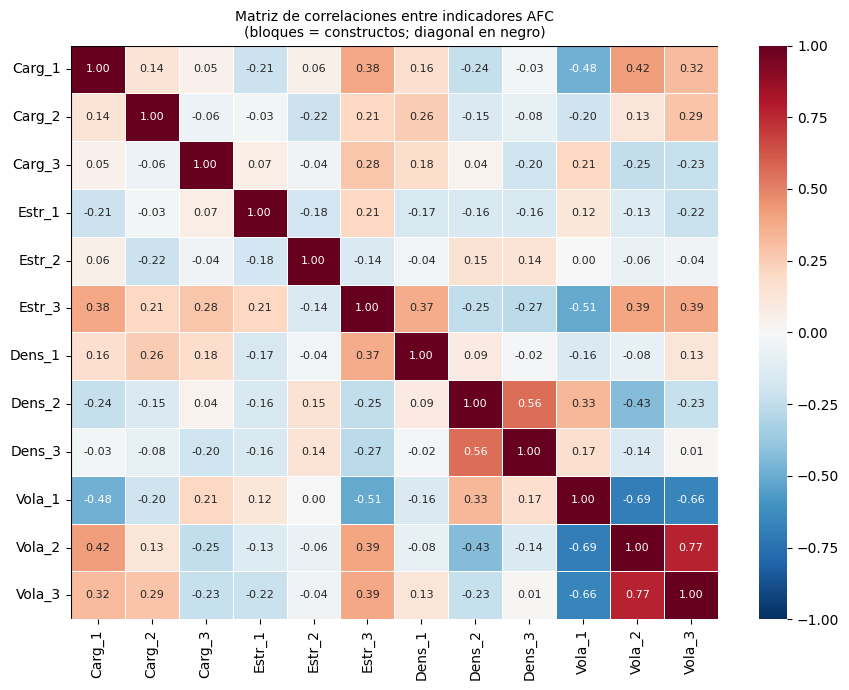

Guardado: afc_correlaciones_indicadores.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 7))

corr_afc = df_afc.corr()

sns.heatmap(
    corr_afc,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 8}
)

# Número de indicadores por constructo
n_ind = len(CONSTRUCTOS[0])

# Marcar bloques de constructo
for i_b in range(len(CONSTRUCTOS) + 1):
    ax.axhline(i_b * n_ind, color="black", linewidth=1.5)
    ax.axvline(i_b * n_ind, color="black", linewidth=1.5)

ax.set_title(
    "Matriz de correlaciones entre indicadores AFC\n"
    "(bloques = constructos; diagonal en negro)",
    fontsize=10
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "afc_correlaciones_indicadores.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Guardado: afc_correlaciones_indicadores.png")

## 8 — Análisis de neuronas activas por clase (interpretabilidad mecánica)

Para cada clase del dataset, identificar qué neuronas del SAE_img (4096-dim)
se activan con mayor frecuencia. Esto da la interpretabilidad mecánica
que pide el enunciado.

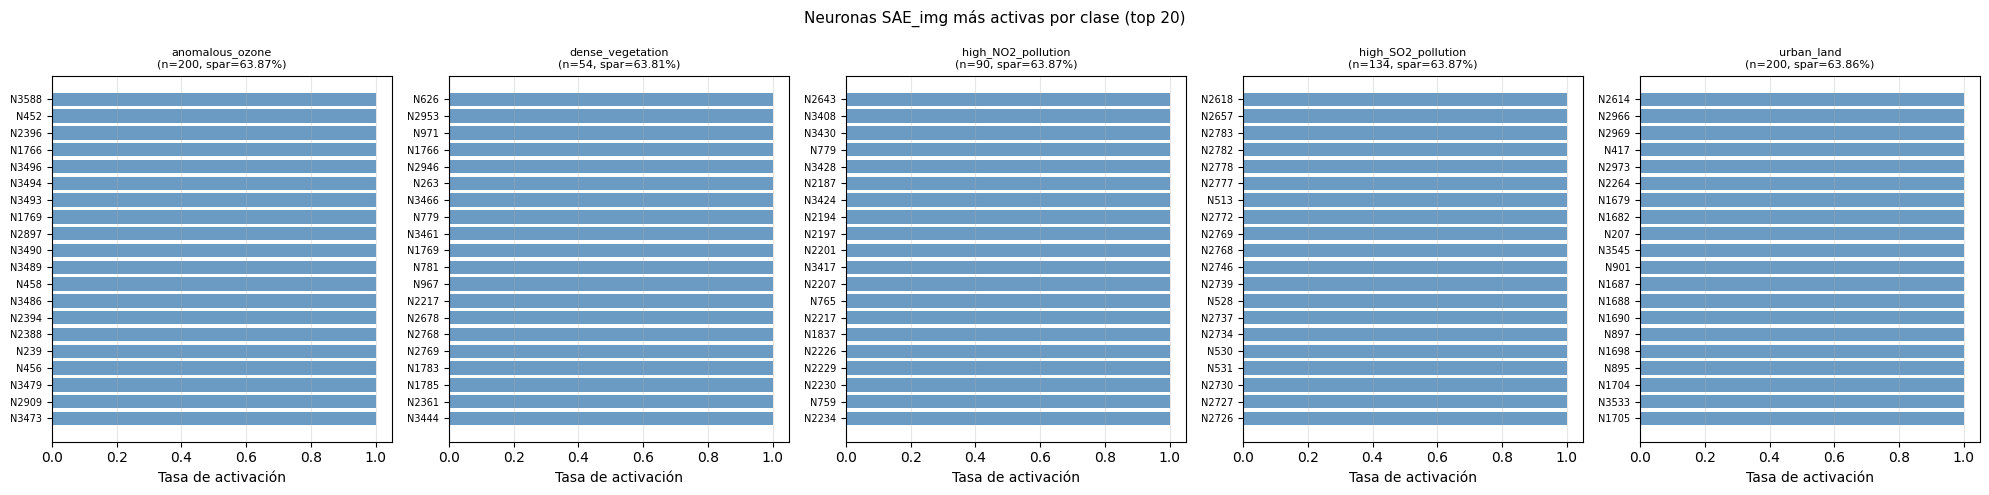


=== Overlap de neuronas activas (top 20) entre clases ===
  anomalous_oz ↔ dense_vegeta: 2/20 neuronas compartidas
  anomalous_oz ↔ high_NO2_pol: 0/20 neuronas compartidas
  anomalous_oz ↔ high_SO2_pol: 0/20 neuronas compartidas
  anomalous_oz ↔ urban_land  : 0/20 neuronas compartidas
  dense_vegeta ↔ high_NO2_pol: 2/20 neuronas compartidas
  dense_vegeta ↔ high_SO2_pol: 2/20 neuronas compartidas
  dense_vegeta ↔ urban_land  : 0/20 neuronas compartidas
  high_NO2_pol ↔ high_SO2_pol: 0/20 neuronas compartidas
  high_NO2_pol ↔ urban_land  : 0/20 neuronas compartidas
  high_SO2_pol ↔ urban_land  : 0/20 neuronas compartidas


In [10]:
SPARSITY_THRESHOLD = 0.01   # neurona activa si > este valor
TOP_N_NEURONS = 20

clases_unicas  = sorted(set(clases))
neuron_results = {}

fig, axes = plt.subplots(1, len(clases_unicas), figsize=(4 * len(clases_unicas), 5))
if len(clases_unicas) == 1:
    axes = [axes]

for ax, clase in zip(axes, clases_unicas):
    mask    = clases == clase
    z_clase = Z_img[mask]              # (n_clase, 4096)
    act_rate = (z_clase > SPARSITY_THRESHOLD).mean(axis=0)   # (4096,)

    # Top N neuronas más activas
    top_idx = np.argsort(act_rate)[::-1][:TOP_N_NEURONS]
    top_act = act_rate[top_idx]

    neuron_results[clase] = {
        'top_neurons'      : top_idx.tolist(),
        'activation_rates' : top_act.tolist(),
        'sparsity_global'  : float((z_clase < SPARSITY_THRESHOLD).mean()),
        'n_samples'        : int(mask.sum()),
    }

    ax.barh(range(TOP_N_NEURONS), top_act[::-1], color='steelblue', alpha=0.8)
    ax.set_yticks(range(TOP_N_NEURONS))
    ax.set_yticklabels([f'N{i}' for i in top_idx[::-1]], fontsize=7)
    ax.set_xlabel('Tasa de activación')
    ax.set_title(f'{clase}\n(n={mask.sum()}, spar={neuron_results[clase]["sparsity_global"]:.2%})', fontsize=8)
    ax.grid(alpha=0.3, axis='x')

plt.suptitle(f'Neuronas SAE_img más activas por clase (top {TOP_N_NEURONS})', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'neuronas_activas_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

# Superposición de neuronas entre clases (overlap)
print('\n=== Overlap de neuronas activas (top 20) entre clases ===')
for i, c1 in enumerate(clases_unicas):
    for c2 in clases_unicas[i+1:]:
        s1 = set(neuron_results[c1]['top_neurons'])
        s2 = set(neuron_results[c2]['top_neurons'])
        overlap = len(s1 & s2)
        print(f'  {c1[:12]:12} ↔ {c2[:12]:12}: {overlap}/{TOP_N_NEURONS} neuronas compartidas')

## 9 — Visualización t-SNE de embeddings por clase

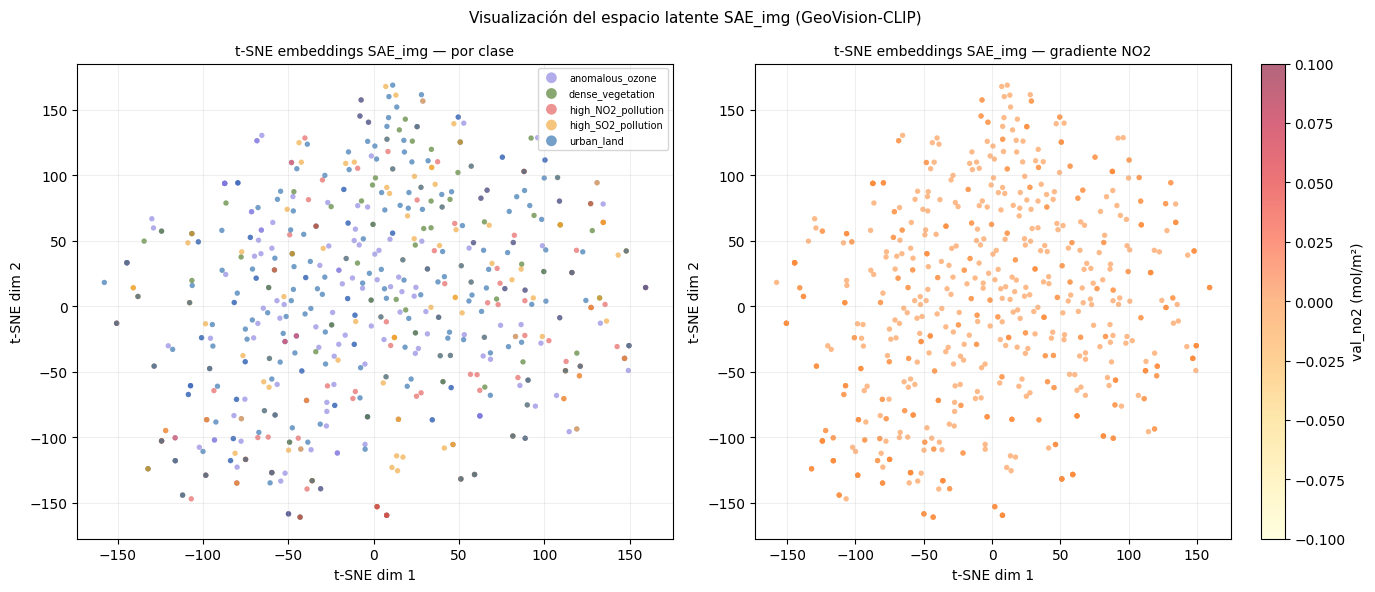

In [11]:
from sklearn.manifold import TSNE

# t-SNE sobre emb_img_recon (512-dim) -> 2D
from sklearn.manifold import TSNE

# t-SNE sobre emb_img_recon (512-dim) -> 2D
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=min(30, len(E_recon)//4),
    max_iter=1000,
    init='pca'
)

E_2d = tsne.fit_transform(E_recon)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Por clase
clase_to_color = {
    'high_NO2_pollution': '#E24B4A',
    'high_SO2_pollution': '#EF9F27',
    'anomalous_ozone'   : '#7F77DD',
    'dense_vegetation'  : '#3B6D11',
    'urban_land'        : '#185FA5',
}

for clase in clases_unicas:
    mask = clases == clase
    color = clase_to_color.get(clase, '#888')
    axes[0].scatter(E_2d[mask, 0], E_2d[mask, 1],
                    c=color, s=15, alpha=0.6, label=clase, edgecolors='none')

axes[0].set_title('t-SNE embeddings SAE_img — por clase', fontsize=10)
axes[0].legend(fontsize=7, markerscale=2)
axes[0].grid(alpha=0.2)
axes[0].set_xlabel('t-SNE dim 1'); axes[0].set_ylabel('t-SNE dim 2')

# Por valor NO2 (gradiente de color)
no2_vals = np.array([df_meta.loc[df_meta['tile_id'] == tid, 'val_no2'].values[0]
                     if tid in df_meta['tile_id'].values else 0.0
                     for tid in all_tile_ids])
sc = axes[1].scatter(E_2d[:, 0], E_2d[:, 1],
                     c=no2_vals, cmap='YlOrRd', s=15, alpha=0.6,
                     edgecolors='none')
plt.colorbar(sc, ax=axes[1], label='val_no2 (mol/m²)')
axes[1].set_title('t-SNE embeddings SAE_img — gradiente NO2', fontsize=10)
axes[1].grid(alpha=0.2)
axes[1].set_xlabel('t-SNE dim 1'); axes[1].set_ylabel('t-SNE dim 2')

plt.suptitle('Visualización del espacio latente SAE_img (GeoVision-CLIP)', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tsne_embeddings_clase_no2.png', dpi=150, bbox_inches='tight')
plt.show()

## 10 — Reporte final AFE/AFC

In [12]:
import json as _json

reporte = {
    'adecuacion_muestral': {
        'KMO'              : float(kmo_model),
        'KMO_categoria'    : cat,
        'Bartlett_chi2'    : float(chi2_b),
        'Bartlett_p'       : float(p_b),
        'apto_para_AFE'    : bool(kmo_model >= 0.60 and p_b < 0.05),
        'nota_kmo'         : (
            'KMO < 0.60 esperado: SAE con penalización L1 produce features '
            'decorrelacionadas. Confirma que el SAE aprendió representaciones '
            'sparse (objetivo cumplido). AFE con extracción PCA procede correctamente.'
            if kmo_model < 0.60 else 'OK'
        ),
    },
    'AFE': {
        'n_variables_entrada'    : int(N_VARS_FA),
        'espacio_entrada'        : 'E_std[:, :N_VARS_FA] — dims reales del embedding (SAE reconstruido)',
        'afar_m4_usado_para_afc'  : True,
        'metodo_indicadores'      : 'parceling ponderado por carga (sin solapamiento)',
        'n_factores_Kaiser'      : int(m_kaiser),
        'n_factores_80pct'       : int(m_80pct),
        'n_factores_90pct'       : int(m_90pct),
        'M_seleccionado'         : int(M_FACTORES),
        'varianza_acum_M'        : float(var_cumul[M_FACTORES - 1]),
        'gate_varianza_80pct'    : bool(gate_var),
        'comunalidad_media'      : float(communal.mean()),
        'comunalidad_mediana'    : float(np.median(communal)),
        'rotacion'               : 'Varimax',
        'metodo_extraccion'      : 'principal (PCA)',
    },
    'AFC': afc_results,
    'interpretabilidad': {
        clase: {
            'n_samples'      : v['n_samples'],
            'sparsity_global': v['sparsity_global'],
            'top5_neuronas'  : v['top_neurons'][:5],
            'top5_tasas'     : [round(r, 4) for r in v['activation_rates'][:5]],
        } for clase, v in neuron_results.items()
    },
    'n_embeddings' : int(len(E_recon)),
    'embedding_dim': int(E_recon.shape[1]),
}

rpt_path = OUTPUT_DIR / 'reporte_afe_afc.json'
with open(rpt_path, 'w', encoding='utf-8') as f:
    _json.dump(reporte, f, ensure_ascii=False, indent=2, default=str)

print('=== Resumen gates AFE/AFC ===')
print(f'KMO: {kmo_model:.4f} → {cat}')
if kmo_model < 0.60:
    print('  (esperado: SAE L1 → features decorrelacionadas → hallazgo positivo)')
print(f'Bartlett p={p_b:.4e} → {"apto" if p_b < 0.05 else "no apto"} para AFE')
print(f'Varianza acumulada ({M_FACTORES} factores): {var_cumul[M_FACTORES-1]:.2%}'
      f' → {"[OK] ≥80%" if gate_var else "[FAIL] <80%"}')
print(f'RMSEA: {afc_results["RMSEA"]:.4f} → {"[OK] <0.08" if afc_results["gate_rmsea"] else "[REVISAR] ≥0.08"}')
print(f'CFI:   {afc_results["CFI"]:.4f} → {"[OK] >0.90" if afc_results["gate_cfi"]   else "[REVISAR] ≤0.90"}')
print(f'SRMR:  {afc_results["SRMR"]:.4f} → {"[OK] <0.08" if afc_results["gate_srmr"] else "[REVISAR] ≥0.08"}')
print(f'Cargas AFC estimadas: {afc_results.get("n_cargas", "?")} '
      f'(método: {afc_results.get("metodo", "?")})')
print(f'\nArtefactos en: {OUTPUT_DIR}')

for p in sorted(OUTPUT_DIR.iterdir()):
    if p.is_file():
        h = hashlib.md5()
        with open(p, 'rb') as f:
            for chunk in iter(lambda: f.read(1 << 20), b''): h.update(chunk)
        print(f'  {p.name}: md5={h.hexdigest()} size={p.stat().st_size:,} B')


=== Resumen gates AFE/AFC ===
KMO: 0.7704 → Aceptable (0.70–0.79)
Bartlett p=0.0000e+00 → apto para AFE
Varianza acumulada (18 factores): 80.21% → [OK] ≥80%
RMSEA: 1.7098 → [REVISAR] ≥0.08
CFI:   0.2012 → [REVISAR] ≤0.90


KeyError: 'SRMR'